In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir=Path("../../../Data/")
log_dir=data_dir/"tuning_trial_2026-04-May_12:01:32"

In [100]:
df = pd.read_csv(log_dir/"scorescollected.csv", header=0)
df.columns = ["dir_path", "design"] + list(df.columns[2:])
df = df.drop(columns=["tcr_chain_index", "mhc_chain_index", *[c for c in df.columns if "cdr" in c]])

In [101]:
df["cond"] = df["dir_path"].map(lambda x: "_".join(x.split("/")[-1].split("_")[2:]))
df["af_tune"] = df["cond"].map(lambda x: not x.isnumeric())
df["iter"] = df["design"].map(lambda x: x.split(".")[0].split("_")[-1])
df.head()

,dir_path,design,score,scaffold,in_pool,cond,af_tune,iter
0,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_0.pdb,2.627191,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,0
1,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,7YV1+MAVMAPRTLV+TLMSAMTNL_0.pdb,3.011980,7YV1+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,0
2,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,7YV1+MAVMAPRTLV+TLMSAMTNL_1.pdb,2.591522,7YV1+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,1
3,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_1.pdb,2.330292,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,1
4,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_2.pdb,2.481159,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,2


In [102]:
#df = df[df["af_tune"]]
df["iter"] = np.array([np.arange(l) for l in df.groupby("cond")["design"].agg(len).to_list()]).flatten()

In [103]:
df.head(20)

,dir_path,design,score,scaffold,in_pool,cond,af_tune,iter
0,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_0.pdb,2.627191,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,0
1,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,7YV1+MAVMAPRTLV+TLMSAMTNL_0.pdb,3.011980,7YV1+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,1
2,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,7YV1+MAVMAPRTLV+TLMSAMTNL_1.pdb,2.591522,7YV1+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,2
3,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_1.pdb,2.330292,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,3
4,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_2.pdb,2.481159,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,4
5,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_3.pdb,2.498335,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,5
6,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_4.pdb,3.603590,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,6
7,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_5.pdb,1.973479,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,7
8,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_6.pdb,2.368120,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,8
9,data/adapt/tuning_trial_2026-04-May_12:01:32/a...,5BS0+MAVMAPRTLV+TLMSAMTNL_7.pdb,1.794124,5BS0+MAVMAPRTLV+TLMSAMTNL,True,params_model_2_multimer_v3,True,9


/tmp/ipykernel_57900/1338871693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub["cond"] = df_sub["cond"].map(lambda x: "\n".join(x.split("_")[1:]))
/tmp/ipykernel_57900/1338871693.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend().remove()
/tmp/ipykernel_57900/1338871693.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


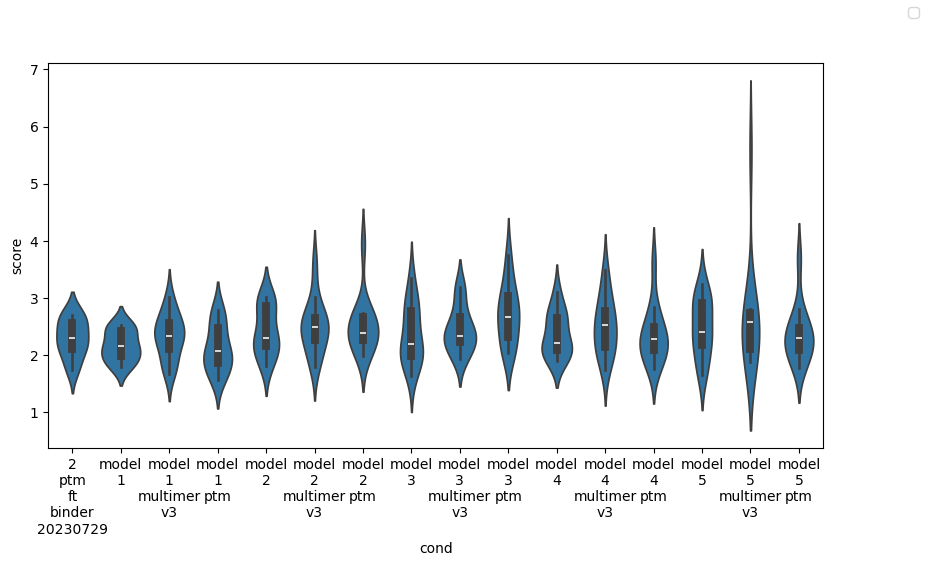

In [104]:
fig,ax=plt.subplots(1,1, figsize=(10,5))
df_sub = df[df["af_tune"]]
df_sub["cond"] = df_sub["cond"].map(lambda x: "\n".join(x.split("_")[1:]))
df_sub = df_sub.sort_values("cond")
if not isinstance(ax, np.ndarray):
    ax = np.array([ax,])
sns.violinplot(
    df_sub,
    x="cond",
    y="score",
    #hue="",
    #legend=False,
    ax = ax[0]
    )

ax[0].legend().remove()
#ax[1].set_axis_off()
fig.legend()

/tmp/ipykernel_57900/1281905404.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub["cond"] = df_sub["cond"].map(int)


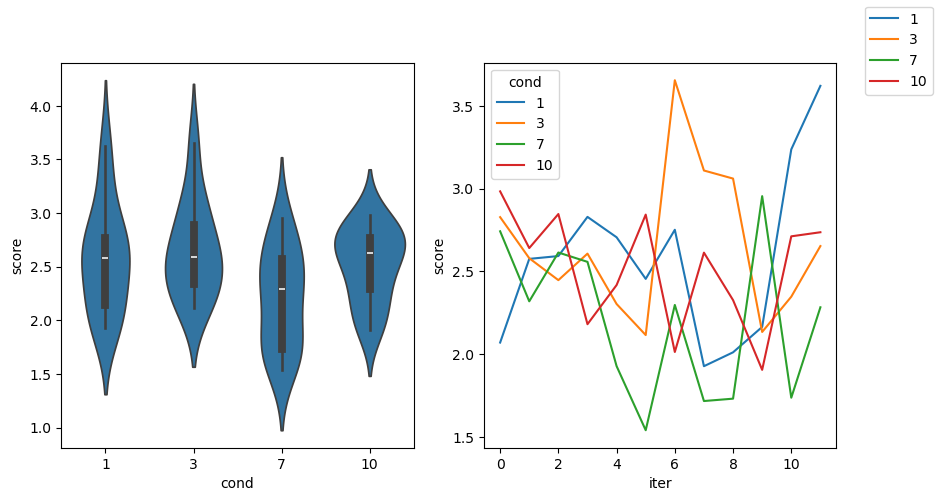

In [116]:
fig,ax=plt.subplots(1,2, figsize=(10,5))
df_sub = df[~df["af_tune"]]
df_sub["cond"] = df_sub["cond"].map(int)
df_sub = df_sub.sort_values("cond")
if not isinstance(ax, np.ndarray):
    ax = np.array([ax,])
sns.violinplot(
    df_sub,
    x="cond",
    y="score",
    #hue="",
    #legend=False,
    ax = ax[0]
    )
sns.lineplot(
    df_sub,
    x="iter",
    y="score",
    hue="cond",
    palette="tab10"
)

fig.legend()